In [10]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [11]:
(x_train, _), (x_test, _) = mnist.load_data()


In [12]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [ ]:
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training Data Shape :", x_train.shape)
print("Testing Data Shape  :", x_test.shape)

Training Data Shape : (60000, 28, 28, 1)
Testing Data Shape  : (10000, 28, 28, 1)


ENCODER


In [ ]:
input_img = Input(shape=(28, 28, 1))

# First Convolution Layer
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)

# First Pooling Layer
x = MaxPooling2D((2,2), padding='same')(x)

# Second Convolution Layer
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)

# Encoded Output
encoded = MaxPooling2D((2,2), padding='same')(x)

DECODER


In [13]:
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)

x = UpSampling2D((2,2))(x)


x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)


AUTOENCODER

In [14]:
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN MODEL


In [15]:
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 236ms/step - loss: 0.1127 - val_loss: 0.0797
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 231ms/step - loss: 0.0777 - val_loss: 0.0747
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 231ms/step - loss: 0.0743 - val_loss: 0.0725
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 232ms/step - loss: 0.0725 - val_loss: 0.0718
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 233ms/step - loss: 0.0713 - val_loss: 0.0701
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 238ms/step - loss: 0.0704 - val_loss: 0.0695
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 235ms/step - loss: 0.0697 - val_loss: 0.0688
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 234ms/step - loss: 0.0692 - val_loss: 0.0684
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - loss: 0.0688 - val_loss: 0.0680
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 230ms/step - loss: 0.0684 - val_loss: 0.0679


In [16]:
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


RESULT

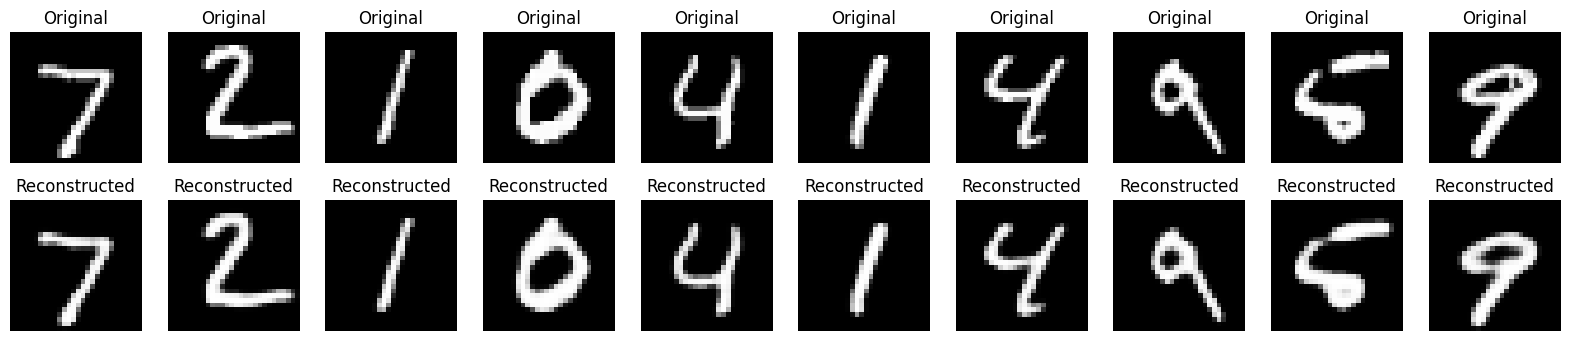

Model Training Completed Successfully!


In [17]:

n = 10  # Number of images

plt.figure(figsize=(20, 4))

for i in range(n):


    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')


    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.savefig("autoencoder_output.png")


plt.show()

print("Model Training Completed Successfully!")